In [1]:
# correlation
# price prediction 

# data combine 
# show correlation



In [2]:
#  data combine 

# get panel data first and add a date column for processing
import pandas as pd
from pandas_datareader import data
tickers = ['AAPL']

start_date = '2020-04-29'
end_date = '2021-10-10'

# User pandas_reader.data.DataReader to load data
panel_data = data.DataReader(tickers,'yahoo', start_date, end_date)
panel_data["date"] = panel_data.index
panel_data["date"] = pd.to_datetime(panel_data['date'])

# get reddit data 
reddit_data = pd.read_csv("./Reddit/cleaned_AAPL_sentiment.csv")
reddit_data["date"] = pd.to_datetime(reddit_data['date']).dt.tz_localize(None)
reddit_data["date"] = pd.to_datetime(reddit_data['date']).dt.date

# get twitter data
twitter_data = pd.read_csv("./Twitter/AAPL_cleaned_sentiment.csv")
twitter_data["date"] = pd.to_datetime(twitter_data['Datetime']).dt.tz_localize(None)
twitter_data["date"] = pd.to_datetime(twitter_data['Datetime']).dt.date

# get stocktwits data
stocktwits_data = pd.read_csv("./Stocktwits/AAPL_cleaned_sentiment.csv")
stocktwits_data["date"] = pd.to_datetime(stocktwits_data['date_created']).dt.tz_localize(None)
stocktwits_data["date"] = pd.to_datetime(stocktwits_data['date_created']).dt.date

# # get news data
# news_data = pd.read_csv("./news/cleaned_AAPL_sentiment.csv")
# news_data["date"] = pd.to_datetime(reddit_data['date'])



In [3]:
# add day names for each of the two df 
from datetime import date
import calendar
for index, row in reddit_data.iterrows():

    reddit_data.at[index,"day_name"] = calendar.day_name[row["date"].weekday()]
    
for index, row in twitter_data.iterrows():

    twitter_data.at[index,"day_name"] = calendar.day_name[row["date"].weekday()]
    
for index, row in stocktwits_data.iterrows():
  
    stocktwits_data.at[index,"day_name"] = calendar.day_name[row["date"].weekday()]

    
    
    
for index, row in panel_data.iterrows():
    date = pd.to_datetime(row["date"].values[0])
    panel_data.at[index,"day_name"]  = calendar.day_name[date.weekday()]

In [4]:
def transform_sentiment(df):
    for index, row in df.iterrows():
        if row['flair_sentiment'] == "NEGATIVE":
            df.at[index,"flair_sentiment_score"] = 0 - row['flair_sentiment_score']
        if row['finbert_sentiment'] == "negative":
            df.at[index,"finbert_score"] = 0 - row['finbert_score']
        if row['finbert_sentiment'] == "neutral":
            df.at[index,"finbert_score"] = 0
    return df

reddit_data = transform_sentiment(reddit_data)
twitter_data = transform_sentiment(twitter_data)
stocktwits_data = transform_sentiment(stocktwits_data)

In [5]:
# groupby dates for panel data and sentiment data  
# note that weekends are missing for panel data
panel_groupby = panel_data.groupby(["date"]).mean()

In [6]:
reddit_groupby = reddit_data.groupby(["date"]).mean()
twitter_groupby = twitter_data.groupby(["date"]).mean()
stocktwits_groupby = stocktwits_data.groupby(["date"]).mean()

In [7]:
panel_data

Attributes,Adj Close,Close,High,Low,Open,Volume,date,day_name
Symbols,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,,
Date,,,,,,,,
2020-04-28,68.888885,69.644997,71.457497,69.550003,71.269997,112004800.0,2020-04-28,Tuesday
2020-04-29,71.151550,71.932503,72.417503,70.972504,71.182503,137280800.0,2020-04-29,Wednesday
2020-04-30,72.652573,73.449997,73.632500,72.087502,72.489998,183064000.0,2020-04-30,Thursday
2020-05-01,71.482918,72.267502,74.750000,71.462502,71.562500,240616800.0,2020-05-01,Friday
2020-05-04,72.494324,73.290001,73.422501,71.580002,72.292503,133568000.0,2020-05-04,Monday
...,...,...,...,...,...,...,...,...
2021-10-04,139.139999,139.139999,142.210007,138.270004,141.759995,98322000.0,2021-10-04,Monday
2021-10-05,141.110001,141.110001,142.240005,139.360001,139.490005,80861100.0,2021-10-05,Tuesday


# correlation test 1 just weekdays drop weekends just apple reddit twitter and stocktwits

C:\Users\Shawn\anaconda3\lib\site-packages\pandas\core\reshape\merge.py:648: UserWarning: merging between different levels can give an unintended result (1 levels on the left,2 on the right)
  warnings.warn(msg, UserWarning)


,flair_sentiment_score,vader_score,finbert_score
likes,-0.181119,0.256752,0.177642
flair_sentiment_score,1.000000,-0.391032,-0.166058
vader_score,-0.391032,1.000000,0.527519
finbert_score,-0.166058,0.527519,1.000000
"(Adj Close, AAPL)",-0.468636,0.526453,0.271362
"(Close, AAPL)",-0.468289,0.526025,0.270229
"(High, AAPL)",-0.476838,0.526877,0.269091
"(Low, AAPL)",-0.472059,0.523649,0.273129
"(Open, AAPL)",-0.479996,0.524990,0.273926
"(Volume, AAPL)",0.237497,-0.335684,-0.310048


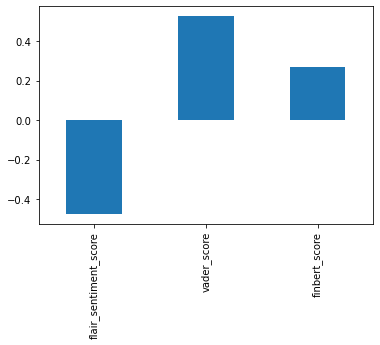

In [8]:
reddit_merge1=pd.merge(reddit_groupby,panel_data, how='inner', left_index=True, right_index=True)
reddit_merge1.corr()[["flair_sentiment_score","vader_score","finbert_score"]].iloc[6].plot(kind="bar")
reddit_merge1.corr()[["flair_sentiment_score","vader_score","finbert_score"]]

C:\Users\Shawn\anaconda3\lib\site-packages\pandas\core\reshape\merge.py:648: UserWarning: merging between different levels can give an unintended result (1 levels on the left,2 on the right)
  warnings.warn(msg, UserWarning)


,flair_sentiment_score,vader_score,finbert_score
Number of Followers,0.024391,0.039509,-0.083838
Number of Comments,0.046660,0.084601,0.015346
Number of Retweets,0.017578,0.075624,0.093738
Number of Likes,0.010330,0.088071,0.097413
flair_sentiment_score,1.000000,0.139407,0.165246
vader_score,0.139407,1.000000,0.225244
finbert_score,0.165246,0.225244,1.000000
"(Adj Close, AAPL)",-0.165775,-0.068900,-0.061459
"(Close, AAPL)",-0.165674,-0.071604,-0.061297
"(High, AAPL)",-0.165353,-0.079201,-0.075311


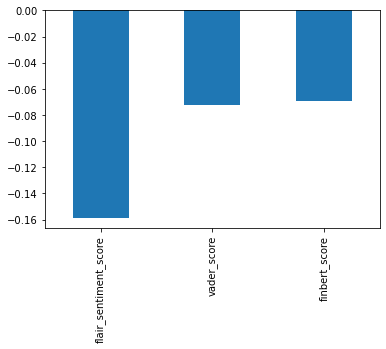

In [9]:
twitter_merge1=pd.merge(twitter_groupby,panel_data, how='inner', left_index=True, right_index=True)
twitter_merge1.corr()[["flair_sentiment_score","vader_score","finbert_score"]].iloc[11].plot(kind="bar")
twitter_merge1.corr()[["flair_sentiment_score","vader_score","finbert_score"]]

C:\Users\Shawn\anaconda3\lib\site-packages\pandas\core\reshape\merge.py:648: UserWarning: merging between different levels can give an unintended result (1 levels on the left,2 on the right)
  warnings.warn(msg, UserWarning)


,flair_sentiment_score,vader_score,finbert_score
person_id,0.054550,0.016114,-0.028080
official,0.252653,0.274761,0.192459
followers,0.246711,0.503609,0.274674
likes,0.228489,0.482212,0.351035
flair_sentiment_score,1.000000,0.652126,0.727533
vader_score,0.652126,1.000000,0.689050
finbert_score,0.727533,0.689050,1.000000
"(Adj Close, AAPL)",0.318349,0.234532,0.244865
"(Close, AAPL)",0.323575,0.238595,0.250684
"(High, AAPL)",0.284990,0.197026,0.216167


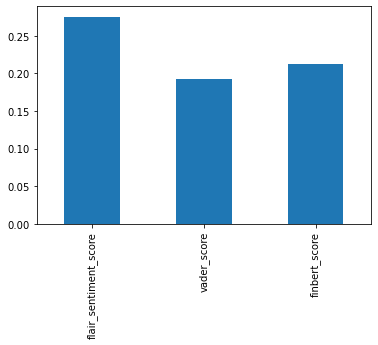

In [10]:
stocktwits_merge1=pd.merge(stocktwits_groupby,panel_data, how='inner', left_index=True, right_index=True)
stocktwits_merge1.corr()[["flair_sentiment_score","vader_score","finbert_score"]].iloc[10].plot(kind="bar").plot(kind="bar")
stocktwits_merge1.corr()[["flair_sentiment_score","vader_score","finbert_score"]]

In [11]:
print("twitter",len(twitter_merge1.index))
print("reddit",len(reddit_merge1.index))
print("stocktwits",len(stocktwits_merge1.index))

twitter 181
reddit 317
stocktwits 170


# correlation test 2 just weekdays drop weekends all stocks

In [12]:
#  data combine 

# get panel data first and add a date column for processing
import pandas as pd
from pandas_datareader import data
tickers = ['AAPL']

start_date = '2020-04-29'
end_date = '2021-10-10'

# User pandas_reader.data.DataReader to load data
panel_data = data.DataReader(tickers,'yahoo', start_date, end_date)
panel_data["date"] = panel_data.index
panel_data["date"] = pd.to_datetime(panel_data['date'])

# get reddit data 
reddit_data = pd.read_csv("reddit_combined.csv")
reddit_data["date"] = pd.to_datetime(reddit_data['date']).dt.tz_localize(None)
reddit_data["date"] = pd.to_datetime(reddit_data['date']).dt.date

# get twitter data
twitter_data = pd.read_csv("twitter_combined.csv")
twitter_data["date"] = pd.to_datetime(twitter_data['Datetime']).dt.tz_localize(None)
twitter_data["date"] = pd.to_datetime(twitter_data['Datetime']).dt.date

# get stocktwits data
stocktwits_data = pd.read_csv("stocktwits_combined.csv")
stocktwits_data["date"] = pd.to_datetime(stocktwits_data['date_created']).dt.tz_localize(None)
stocktwits_data["date"] = pd.to_datetime(stocktwits_data['date_created']).dt.date

# # get news data
# news_data = pd.read_csv("./news/cleaned_AAPL_sentiment.csv")
# news_data["date"] = pd.to_datetime(reddit_data['date'])

 

In [14]:

def transform_sentiment(df):
    for index, row in df.iterrows():
        if row['flair_sentiment'] == "NEGATIVE":
            df.at[index,"flair_score"] = 0 - row['flair_sentiment_score']
        if row['finbert_sentiment'] == "negative":
            df.at[index,"finbert_score"] = 0 - row['finbert_score']
        if row['finbert_sentiment'] == "neutral":
            df.at[index,"finbert_score"] = 0
    return df

reddit_data = transform_sentiment(reddit_data)
twitter_data = transform_sentiment(twitter_data)
stocktwits_data = transform_sentiment(stocktwits_data)

panel_groupby = panel_data.groupby(["date"]).mean()
reddit_groupby = reddit_data.groupby(["date"]).mean()
twitter_groupby = twitter_data.groupby(["date"]).mean()
stocktwits_groupby = stocktwits_data.groupby(["date"]).mean()

C:\Users\Shawn\anaconda3\lib\site-packages\pandas\core\reshape\merge.py:648: UserWarning: merging between different levels can give an unintended result (1 levels on the left,2 on the right)
  warnings.warn(msg, UserWarning)


,flair_sentiment_score,vader_score,finbert_score
likes,0.033382,0.185139,0.042317
flair_sentiment_score,1.000000,0.052058,-0.145505
vader_score,0.052058,1.000000,0.607476
finbert_score,-0.145505,0.607476,1.000000
flair_score,-0.758945,-0.218230,0.051943
"(Adj Close, AAPL)",0.187168,0.572628,0.275869
"(Close, AAPL)",0.186723,0.572141,0.275325
"(High, AAPL)",0.196148,0.579106,0.276224
"(Low, AAPL)",0.192417,0.570355,0.276858
"(Open, AAPL)",0.200738,0.576240,0.278913


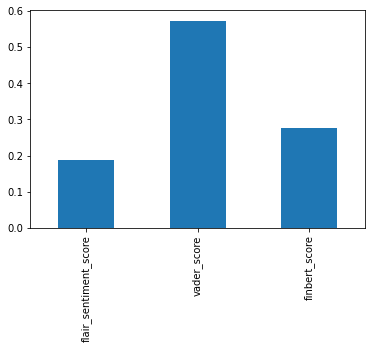

In [15]:
reddit_merge2=pd.merge(reddit_groupby,panel_data, how='inner', left_index=True, right_index=True)
reddit_merge2.corr()[["flair_sentiment_score","vader_score","finbert_score"]].iloc[6].plot(kind="bar")
reddit_merge2.corr()[["flair_sentiment_score","vader_score","finbert_score"]]

C:\Users\Shawn\anaconda3\lib\site-packages\pandas\core\reshape\merge.py:648: UserWarning: merging between different levels can give an unintended result (1 levels on the left,2 on the right)
  warnings.warn(msg, UserWarning)


,flair_sentiment_score,vader_score,finbert_score
Number of Followers,-0.040175,-0.073544,0.045299
Number of Comments,0.089029,-0.110626,-0.146267
Number of Retweets,-0.028168,-0.040004,-0.092122
Number of Likes,-0.038176,0.034841,-0.019308
flair_sentiment_score,1.000000,-0.148994,-0.249707
vader_score,-0.148994,1.000000,0.343179
finbert_score,-0.249707,0.343179,1.000000
flair_score,-0.817882,0.205583,0.270010
"(Adj Close, AAPL)",-0.017999,0.041128,0.098017
"(Close, AAPL)",-0.019653,0.040349,0.100974


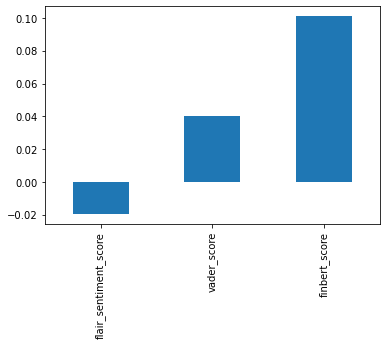

In [16]:
twitter_merge2=pd.merge(twitter_groupby,panel_data, how='inner', left_index=True, right_index=True)
twitter_merge2.corr()[["flair_sentiment_score","vader_score","finbert_score"]].iloc[9].plot(kind="bar")
twitter_merge2.corr()[["flair_sentiment_score","vader_score","finbert_score"]]

C:\Users\Shawn\anaconda3\lib\site-packages\pandas\core\reshape\merge.py:648: UserWarning: merging between different levels can give an unintended result (1 levels on the left,2 on the right)
  warnings.warn(msg, UserWarning)


,flair_sentiment_score,vader_score,finbert_score
person_id,-0.036375,-0.280750,-0.130194
official,-0.430230,0.495105,0.424242
followers,-0.131787,0.524977,0.141914
likes,-0.019368,0.367498,0.152367
flair_sentiment_score,1.000000,-0.427639,-0.775412
vader_score,-0.427639,1.000000,0.640221
finbert_score,-0.775412,0.640221,1.000000
flair_score,-0.908763,0.524641,0.746835
"(Adj Close, AAPL)",-0.182581,-0.008822,0.182925
"(Close, AAPL)",-0.185558,-0.001826,0.189278


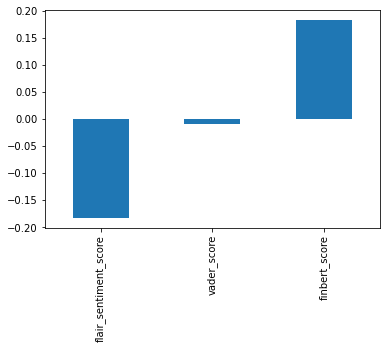

In [17]:



stocktwits_groupby["date"] = stocktwits_groupby.index
stocktwits_groupby["date"] = pd.to_datetime(stocktwits_groupby['date'])

stocktwits_merge2 = pd.merge(stocktwits_groupby,panel_data,how='inner', left_index=True, right_index=True)
stocktwits_merge2.corr()[["flair_sentiment_score","vader_score","finbert_score"]].iloc[8].plot(kind="bar")
stocktwits_merge2.corr()[["flair_sentiment_score","vader_score","finbert_score"]]

In [18]:
print("twitter",len(twitter_merge2.index))
print("reddit",len(reddit_merge2.index))
print("stocktwits",len(stocktwits_merge2.index))

twitter 188
reddit 319
stocktwits 195


# correlation test 3 weighted sentiment weekdays drop weekends all stocks

In [42]:
#  missing weekends - add weekend prices, leave it at friday 
#  use the weighted sentiment 

def weighted_weekends(data):
    weighted_flair = weighted_vader = weighted_finbert = 0
    new_df = []
    for index, row in data.iterrows():
        day_name = row["day_name"]
        if (day_name == "Saturday"): # saturday
            weighted_flair += row['flair_sentiment_score'] * 0.2
            weighted_vader += row['vader_score'] * 0.2
            weighted_finbert += row['finbert_score'] * 0.2
            new_df.append([index, row['flair_sentiment_score'], row['vader_score'], row['finbert_score']])
        elif (day_name == "Sunday"): # sunday
            weighted_flair += row['flair_sentiment_score'] * 0.3
            weighted_vader += row['vader_score'] * 0.3
            weighted_finbert += row['finbert_score'] * 0.3
            new_df.append([index, row['flair_sentiment_score'], row['vader_score'], row['finbert_score']])
        elif (day_name == "Monday"): # monday
            weighted_flair += row['flair_sentiment_score'] * 0.5
            weighted_vader += row['vader_score'] * 0.5
            weighted_finbert += row['finbert_score'] * 0.5
            new_df.append([index, weighted_flair, weighted_vader, weighted_finbert])
            weighted_flair = weighted_vader = weighted_finbert = 0
            
        else:
            new_df.append([index, row['flair_sentiment_score'], row['vader_score'], row['finbert_score']])
            
    return new_df

In [47]:
reddit_groupby["date"] = reddit_groupby.index
reddit_groupby["date"] = pd.to_datetime(reddit_groupby['date'])
for index, row in reddit_groupby.iterrows():
    date = pd.to_datetime(row["date"])
    reddit_groupby.at[index,"day_name"]  = calendar.day_name[date.weekday()]
    
twitter_groupby["date"] = twitter_groupby.index
twitter_groupby["date"] = pd.to_datetime(twitter_groupby['date'])
for index, row in twitter_groupby.iterrows():
    date = pd.to_datetime(row["date"])
    twitter_groupby.at[index,"day_name"]  = calendar.day_name[date.weekday()]
    
stocktwits_groupby["date"] = stocktwits_groupby.index
stocktwits_groupby["date"] = pd.to_datetime(stocktwits_groupby['date'])
for index, row in stocktwits_groupby.iterrows():
    date = pd.to_datetime(row["date"])
    stocktwits_groupby.at[index,"day_name"]  = calendar.day_name[date.weekday()]
    

C:\Users\Shawn\anaconda3\lib\site-packages\pandas\core\reshape\merge.py:648: UserWarning: merging between different levels can give an unintended result (1 levels on the left,2 on the right)
  warnings.warn(msg, UserWarning)


,flair_sentiment_score,vader_score,finbert_score
flair_sentiment_score,1.000000,-0.438851,-0.780710
vader_score,-0.438851,1.000000,0.589177
finbert_score,-0.780710,0.589177,1.000000
"(Adj Close, AAPL)",-0.181775,0.015258,0.199094
"(Close, AAPL)",-0.184696,0.021109,0.205191
"(High, AAPL)",-0.167816,-0.021503,0.179091
"(Low, AAPL)",-0.171667,-0.019121,0.185763
"(Open, AAPL)",-0.156664,-0.045248,0.166401
"(Volume, AAPL)",0.091552,-0.090756,-0.150918


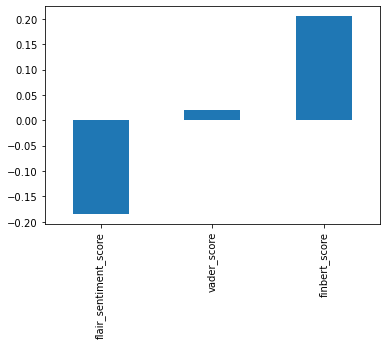

In [48]:
stocktwits_groupby
stocktwits_weight = weighted_weekends(stocktwits_groupby)
stocktwits_weighted = pd.DataFrame(stocktwits_weight, columns=["date","flair_sentiment_score","vader_score","finbert_score"])
stocktwits_weighted


stocktwits_weighted['date'] = stocktwits_weighted['date'].astype(str)
panel_data['date'] = panel_data['date'].astype(str)
stocktwits_merge3 = pd.merge(stocktwits_weighted,panel_data, on="date")
stocktwits_merge3.corr()[["flair_sentiment_score","vader_score","finbert_score"]].iloc[4].plot(kind="bar")
stocktwits_merge3.corr()[["flair_sentiment_score","vader_score","finbert_score"]]

C:\Users\Shawn\anaconda3\lib\site-packages\pandas\core\reshape\merge.py:648: UserWarning: merging between different levels can give an unintended result (1 levels on the left,2 on the right)
  warnings.warn(msg, UserWarning)


,flair_sentiment_score,vader_score,finbert_score
flair_sentiment_score,1.000000,0.096314,-0.086012
vader_score,0.096314,1.000000,0.642443
finbert_score,-0.086012,0.642443,1.000000
"(Adj Close, AAPL)",-0.062563,0.543471,0.304623
"(Close, AAPL)",-0.063263,0.542796,0.304276
"(High, AAPL)",-0.061029,0.549465,0.305579
"(Low, AAPL)",-0.059278,0.541650,0.305798
"(Open, AAPL)",-0.058880,0.545990,0.308568
"(Volume, AAPL)",0.014212,-0.340096,-0.282691


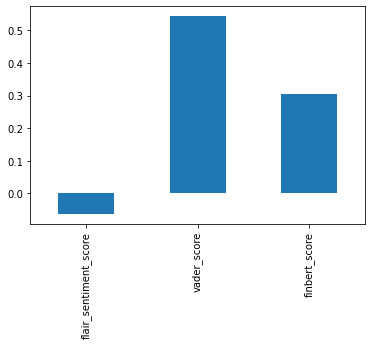

In [49]:
reddit_groupby
reddit_weight = weighted_weekends(reddit_groupby)
reddit_weighted = pd.DataFrame(reddit_weight, columns=["date","flair_sentiment_score","vader_score","finbert_score"])
reddit_weighted


reddit_weighted['date'] = reddit_weighted['date'].astype(str)
panel_data['date'] = panel_data['date'].astype(str)
reddit_merge3 = pd.merge(reddit_weighted,panel_data, on="date")
reddit_merge3.corr()[["flair_sentiment_score","vader_score","finbert_score"]].iloc[4].plot(kind="bar")
reddit_merge3.corr()[["flair_sentiment_score","vader_score","finbert_score"]]

C:\Users\Shawn\anaconda3\lib\site-packages\pandas\core\reshape\merge.py:648: UserWarning: merging between different levels can give an unintended result (1 levels on the left,2 on the right)
  warnings.warn(msg, UserWarning)


,flair_sentiment_score,vader_score,finbert_score
flair_sentiment_score,1.000000,-0.155331,-0.249860
vader_score,-0.155331,1.000000,0.300521
finbert_score,-0.249860,0.300521,1.000000
"(Adj Close, AAPL)",-0.014246,0.027074,0.103042
"(Close, AAPL)",-0.015750,0.026069,0.105732
"(High, AAPL)",-0.010717,0.022800,0.083553
"(Low, AAPL)",-0.012313,0.029495,0.097074
"(Open, AAPL)",-0.014734,0.028391,0.080835
"(Volume, AAPL)",-0.058338,-0.057173,-0.127036


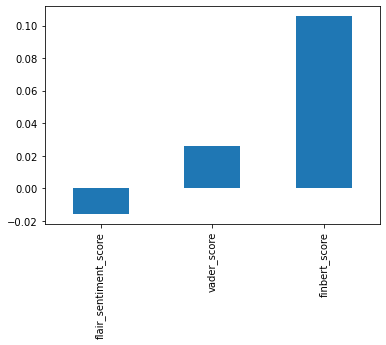

In [50]:
twitter_groupby
twitter_weight = weighted_weekends(twitter_groupby)
twitter_weighted = pd.DataFrame(twitter_weight, columns=["date","flair_sentiment_score","vader_score","finbert_score"])
twitter_weighted


twitter_weighted['date'] = twitter_weighted['date'].astype(str)
panel_data['date'] = panel_data['date'].astype(str)
twitter_merge3 = pd.merge(twitter_weighted,panel_data, on="date")
twitter_merge3.corr()[["flair_sentiment_score","vader_score","finbert_score"]].iloc[4].plot(kind="bar")
twitter_merge3.corr()[["flair_sentiment_score","vader_score","finbert_score"]]

In [51]:
print("twitter",len(twitter_merge3.index))
print("reddit",len(reddit_merge3.index))
print("stocktwits",len(stocktwits_merge3.index))

twitter 188
reddit 319
stocktwits 195


# correlation test 4 weekend equal friday price include weekends all stocks

C:\Users\Shawn\anaconda3\lib\site-packages\pandas\core\reshape\merge.py:648: UserWarning: merging between different levels can give an unintended result (1 levels on the left,2 on the right)
  warnings.warn(msg, UserWarning)


,flair_sentiment_score,vader_score,finbert_score
person_id,-0.076905,-0.103467,-0.094891
official,-0.308441,0.543079,0.309827
followers,-0.219340,0.573366,0.192661
likes,-0.095794,0.617231,0.289392
flair_sentiment_score,1.000000,-0.370407,-0.616224
vader_score,-0.370407,1.000000,0.598603
finbert_score,-0.616224,0.598603,1.000000
flair_score,-0.891736,0.450235,0.601513
"(Adj Close, AAPL)",-0.178195,0.004845,0.182303
"(Close, AAPL)",-0.180318,0.008491,0.188134


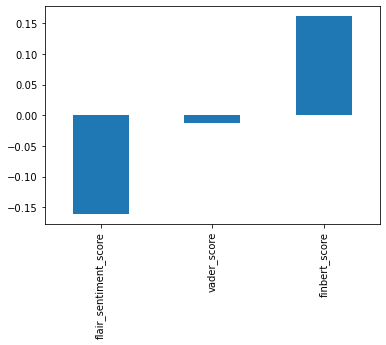

In [52]:
# add price to weekends 

stocktwits_groupby["date"] = stocktwits_groupby.index
stocktwits_groupby["date"] = pd.to_datetime(stocktwits_groupby['date'])
 

stocktwits_groupby.index.name = None
panel_data.index.name = None
panel_data["date"] = pd.to_datetime(panel_data['date'])

stocktwits_merge4 = pd.merge(stocktwits_groupby,panel_data, on='date', how='left')
stocktwits_merge4.fillna(method='ffill', inplace=True)
stocktwits_merge4 = stocktwits_merge4.dropna()

stocktwits_merge4.corr()[["flair_sentiment_score","vader_score","finbert_score"]].iloc[10].plot(kind="bar")
stocktwits_merge4.corr()[["flair_sentiment_score","vader_score","finbert_score"]]


C:\Users\Shawn\anaconda3\lib\site-packages\pandas\core\reshape\merge.py:648: UserWarning: merging between different levels can give an unintended result (1 levels on the left,2 on the right)
  warnings.warn(msg, UserWarning)


,flair_sentiment_score,vader_score,finbert_score
likes,-0.014118,0.073347,0.029773
flair_sentiment_score,1.000000,-0.003923,-0.171572
vader_score,-0.003923,1.000000,0.639717
finbert_score,-0.171572,0.639717,1.000000
flair_score,-0.798848,-0.163554,0.072392
"(Adj Close, AAPL)",0.143427,0.523868,0.292420
"(Close, AAPL)",0.142921,0.523309,0.292180
"(High, AAPL)",0.146950,0.528147,0.293290
"(Low, AAPL)",0.147737,0.524535,0.293107
"(Open, AAPL)",0.153464,0.528698,0.293664


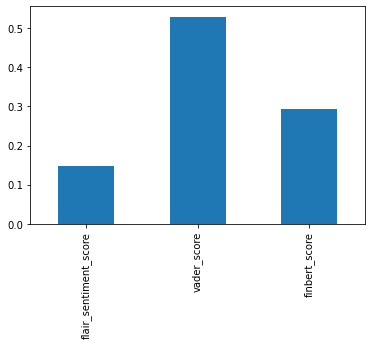

In [53]:
# add price to weekends 

reddit_groupby["date"] = reddit_groupby.index
reddit_groupby["date"] = pd.to_datetime(reddit_groupby['date'])

reddit_groupby.index.name = None
panel_data.index.name = None
panel_data["date"] = pd.to_datetime(panel_data['date'])

reddit_merge4 = pd.merge(reddit_groupby,panel_data, on='date', how='left')
reddit_merge4.fillna(method='ffill', inplace=True)
reddit_merge4 = reddit_merge4.dropna()

reddit_merge4.corr()[["flair_sentiment_score","vader_score","finbert_score"]].iloc[7].plot(kind="bar")
reddit_merge4.corr()[["flair_sentiment_score","vader_score","finbert_score"]]

C:\Users\Shawn\anaconda3\lib\site-packages\pandas\core\reshape\merge.py:648: UserWarning: merging between different levels can give an unintended result (1 levels on the left,2 on the right)
  warnings.warn(msg, UserWarning)


,flair_sentiment_score,vader_score,finbert_score
Number of Followers,-0.018841,0.060959,0.081098
Number of Comments,0.058803,0.019302,-0.042799
Number of Retweets,0.005532,-0.031081,0.024465
Number of Likes,-0.016787,0.049584,0.075113
flair_sentiment_score,1.000000,-0.067893,-0.199818
vader_score,-0.067893,1.000000,0.294286
finbert_score,-0.199818,0.294286,1.000000
flair_score,-0.740330,0.161167,0.193249
"(Adj Close, AAPL)",-0.069295,0.018976,0.070679
"(Close, AAPL)",-0.070415,0.017652,0.072603


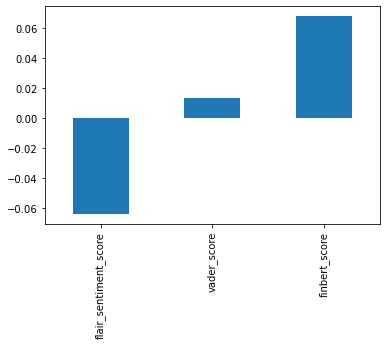

In [54]:
# add price to weekends 

twitter_groupby["date"] = twitter_groupby.index
twitter_groupby["date"] = pd.to_datetime(twitter_groupby['date'])

twitter_groupby.index.name = None
panel_data.index.name = None
panel_data["date"] = pd.to_datetime(panel_data['date'])

twitter_merge4 = pd.merge(twitter_groupby,panel_data, on='date', how='left')
twitter_merge4.fillna(method='ffill', inplace=True)
twitter_merge4 = twitter_merge4.dropna()

twitter_merge4.corr()[["flair_sentiment_score","vader_score","finbert_score"]].iloc[10].plot(kind="bar")
twitter_merge4.corr()[["flair_sentiment_score","vader_score","finbert_score"]]

In [55]:
columns = ["flair_sentiment_score","vader_score","finbert_score","platform"]

dropall = []
dropall.append(reddit_merge2.corr()[["flair_sentiment_score","vader_score","finbert_score"]].iloc[6].tolist())
dropall.append(twitter_merge2.corr()[["flair_sentiment_score","vader_score","finbert_score"]].iloc[9].tolist())
dropall.append(stocktwits_merge2.corr()[["flair_sentiment_score","vader_score","finbert_score"]].iloc[8].tolist())
dropall[0].append("reddit")
dropall[1].append("twitter")
dropall[2].append("stocktwits")
dropall = pd.DataFrame(dropall,columns=columns)
dropall = dropall.set_index("platform")


weighteddrop = []
weighteddrop.append(reddit_merge3.corr()[["flair_sentiment_score","vader_score","finbert_score"]].iloc[4].tolist())
weighteddrop.append(twitter_merge3.corr()[["flair_sentiment_score","vader_score","finbert_score"]].iloc[4].tolist())
weighteddrop.append(stocktwits_merge3.corr()[["flair_sentiment_score","vader_score","finbert_score"]].iloc[4].tolist())
weighteddrop[0].append("reddit")
weighteddrop[1].append("twitter")
weighteddrop[2].append("stocktwits")
weighteddrop = pd.DataFrame(weighteddrop,columns=columns)
weighteddrop = weighteddrop.set_index("platform")

forwardnodrop = []
forwardnodrop.append(reddit_merge4.corr()[["flair_sentiment_score","vader_score","finbert_score"]].iloc[7].tolist())
forwardnodrop.append(twitter_merge4.corr()[["flair_sentiment_score","vader_score","finbert_score"]].iloc[10].tolist())
forwardnodrop.append(stocktwits_merge4.corr()[["flair_sentiment_score","vader_score","finbert_score"]].iloc[10].tolist())
forwardnodrop[0].append("reddit")
forwardnodrop[1].append("twitter")
forwardnodrop[2].append("stocktwits")
forwardnodrop = pd.DataFrame(forwardnodrop,columns=columns)
forwardnodrop = forwardnodrop.set_index("platform")

<ipython-input-100-fdd4265d4d02>:8: MatplotlibDeprecationWarning: The 's' parameter of annotate() has been renamed 'text' since Matplotlib 3.3; support for the old name will be dropped two minor releases later.
  ax.annotate(s=np.round(p.get_height(), decimals=2),
<ipython-input-100-fdd4265d4d02>:20: MatplotlibDeprecationWarning: The 's' parameter of annotate() has been renamed 'text' since Matplotlib 3.3; support for the old name will be dropped two minor releases later.
  ax.annotate(s=np.round(p.get_height(), decimals=2),
<ipython-input-100-fdd4265d4d02>:32: MatplotlibDeprecationWarning: The 's' parameter of annotate() has been renamed 'text' since Matplotlib 3.3; support for the old name will be dropped two minor releases later.
  ax.annotate(s=np.round(p.get_height(), decimals=2),


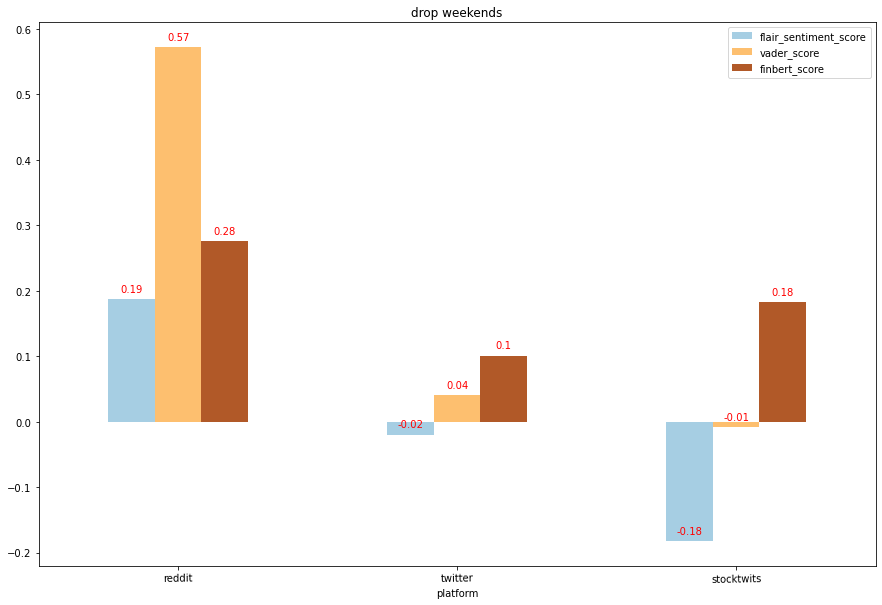

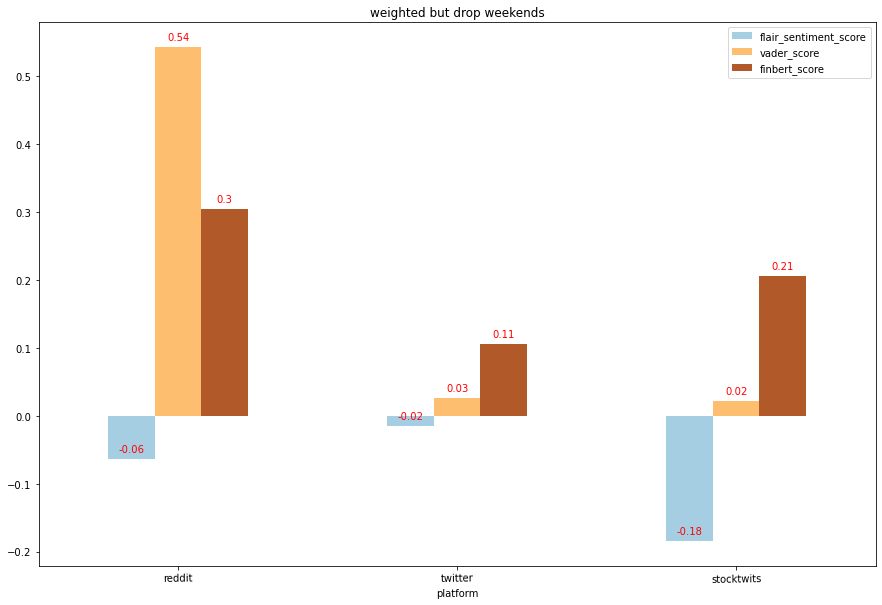

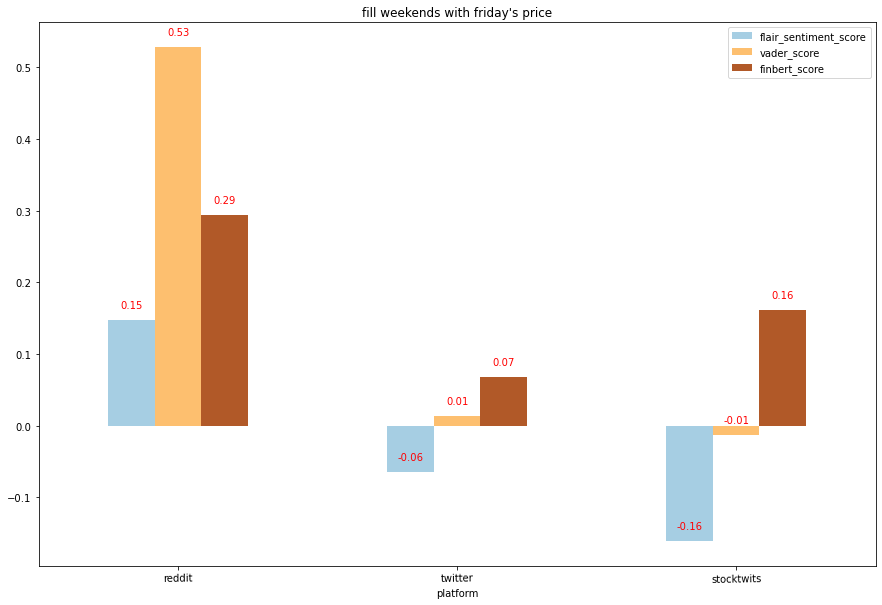

In [100]:
from matplotlib import pyplot as plt
import numpy as np

ax = dropall.plot(kind="bar",figsize=(15,10), colormap='Paired')
plt.xticks(rotation=1)
plt.title("drop weekends")
for p in ax.patches:
    ax.annotate(s=np.round(p.get_height(), decimals=2),
                xy=(p.get_x()+p.get_width()/2., p.get_height()),                
                ha='center',
                va='center',
                xytext=(0, 10),
                textcoords='offset points',
                color="red")
    
ax =weighteddrop.plot(kind="bar",figsize=(15,10), colormap='Paired')
plt.xticks(rotation=1)
plt.title("weighted but drop weekends")
for p in ax.patches:
    ax.annotate(s=np.round(p.get_height(), decimals=2),
                xy=(p.get_x()+p.get_width()/2., p.get_height()),                
                ha='center',
                va='center',
                xytext=(0, 10),
                textcoords='offset points',
                color="red")

ax = forwardnodrop.plot(kind="bar",figsize=(15,10), colormap='Paired')
plt.xticks(rotation=1)
plt.title("fill weekends with friday's price")
for p in ax.patches:
    ax.annotate(s=np.round(p.get_height(), decimals=2),
                xy=(p.get_x()+p.get_width()/2., p.get_height()),                
                ha='center',
                va='center',
                xytext=(0, 15),
                textcoords='offset points',
                color="red")

In [ ]:
# train linear regression on one year worth of data
# store linear regression model in flask
# predict estimated price based on that day's sentiment 
# display result 


In [102]:
reddit_merge2.to_csv("reddit_merged.csv",index=False)
twitter_merge2.to_csv("twitter_merged.csv",index=False)
stocktwits_merge2.to_csv("stocktwits_merged.csv",index=False)